# PTB-XL — Tidy, Modular Notebook (v3, with FFT/SMOTE/Deep Hybrid)

# 0) Config — paths, toggles, label mode

In [1]:

# -------- Global Config --------
CFG = {
    # Root folder that contains ptbxl_database.csv, scp_statements.csv, and records100/
    "PTBXL_ROOT": "dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3",
    # 'filename_lr' (100 Hz) or 'filename_hr' (500 Hz)
    "RECORD_FILE_COL": "filename_lr",
    # Label granularity: '5class' uses diagnostic_class; '10class' uses diagnostic_subclass
    "LABEL_MODE": "5class",
    # Fast mode: limit records & skip DL/FL
    "FAST_RUN": False,               # set True for quick smoke-tests
    "MAX_RECORDS": None,             # e.g., 200 in FAST_RUN
    "USE_FEATURE_CACHE": True,       # reuse feature CSV if present

    # Artifacts & cache
    "ART_DIR": "test/artifacts",
    "CACHE_DIR": "./sk_cache",
    # Extended EDA heavies (VIF/PCA); set True to skip on big runs
    "EDA_SKIP_HEAVY": False,
    # Random seed
    "SEED": 42,

    # === Classical ML toggles ===
    "RUN_SMOTE": True,               # enable SMOTE by default (train-only)
    "ADD_FFT_FEATURES": True,        # add FFT/PSD per-lead features
    "DEEP_HYBRID": False,            # heavy; set True to run RNN→LSTM→GRU→RF
    "BINARY_TASK": False,            # reproduce paper's binary experiments
    "BINARY_SCHEME": "NORM_vs_ALL",  # or "NORM_vs_HYP"
    "FORCE_SPLIT_80_20": False,      # keep False to use PTB-XL strat_fold by default

    # === NEW: Keras deep models on raw signals ===
    "RUN_TF_CNN": True,              # 1D CNN on (T,12)
    "RUN_TF_RNN": True,              # SimpleRNN stack
    "RUN_TF_LSTM": True,             # LSTM stack
    "SEQ_LEN": 1000,                 # crop/pad length @100 Hz (~10s)
    "BATCH_SIZE": 128,
    "EPOCHS": 30                     # set lower (e.g., 5) for FAST_RUN
}

if CFG["FAST_RUN"] and (CFG["MAX_RECORDS"] is None):
    CFG["MAX_RECORDS"] = 200  # sensible default for quick runs
if CFG["FAST_RUN"]:
    CFG["EPOCHS"] = min(CFG["EPOCHS"], 5)

print(CFG)


{'PTBXL_ROOT': 'dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3', 'RECORD_FILE_COL': 'filename_lr', 'LABEL_MODE': '5class', 'FAST_RUN': False, 'MAX_RECORDS': None, 'USE_FEATURE_CACHE': True, 'ART_DIR': 'test/artifacts', 'CACHE_DIR': './sk_cache', 'EDA_SKIP_HEAVY': False, 'SEED': 42, 'RUN_SMOTE': True, 'ADD_FFT_FEATURES': True, 'DEEP_HYBRID': False, 'BINARY_TASK': False, 'BINARY_SCHEME': 'NORM_vs_ALL', 'FORCE_SPLIT_80_20': False}


# 1) Setup & Reproducibility

In [2]:

# Optional installs (uncomment as needed)
# %pip install -q wfdb imblearn tensorflow==2.16.* scikeras

import os, random, time, json, warnings, ast, itertools, zipfile, glob, sys, subprocess
import numpy as np
import pandas as pd
from IPython.display import display
warnings.filterwarnings("ignore")

SEED = CFG["SEED"]
random.seed(SEED); np.random.seed(SEED)

# Torch is optional
try:
    import torch
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    TORCH_OK = True
except Exception:
    TORCH_OK = False

def ts() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")

def log(msg: str):
    print(f"[{ts()}] {msg}")

# show key library versions
try:
    from importlib.metadata import version
    log("Versions — pandas %s, numpy %s" % (version("pandas"), version("numpy")))
except Exception:
    pass

log(f"Seeds set. Torch available: {TORCH_OK}")


[2025-10-07 17:19:53] Versions — pandas 2.3.2, numpy 2.3.3
[2025-10-07 17:19:53] Seeds set. Torch available: True


# 2) Paths & Sanity Checks

In [3]:

from pathlib import Path
from scipy.stats import skew, kurtosis

ROOT = Path(CFG["PTBXL_ROOT"])
DB_CSV  = ROOT / "ptbxl_database.csv"
SCP_CSV = ROOT / "scp_statements.csv"
RECORDS_DIR = ROOT / "records100"  # required for filename_lr

assert DB_CSV.exists(),  f"Missing {DB_CSV}"
assert SCP_CSV.exists(), f"Missing {SCP_CSV}"
assert RECORDS_DIR.exists(), "Missing records100/ (for low-rate signals)"

# WFDB required for signal reading
try:
    import wfdb
except ImportError as e:
    raise RuntimeError("Please install WFDB:  %pip install wfdb") from e

# sanity read (not fatal)
try:
    sig0, meta0 = wfdb.rdsamp(str(RECORDS_DIR / "00000" / "00001_lr"))
    log(f"WFDB sanity OK: shape={sig0.shape}, leads={meta0.get('sig_name', [])}")
except Exception as e:
    log(f"WFDB sanity read failed (not fatal): {e}")


[2025-10-07 17:19:54] WFDB sanity OK: shape=(1000, 12), leads=['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


# 3) Load CSVs

In [4]:

db  = pd.read_csv(DB_CSV)
scp_raw = pd.read_csv(SCP_CSV, encoding="utf-8-sig")
scp_raw.columns = [str(c).strip() for c in scp_raw.columns]
log(f"Loaded db: {db.shape}, scp_statements: {scp_raw.shape}")
display(db.head(2)); display(scp_raw.head(2))


[2025-10-07 17:19:54] Loaded db: (21799, 28), scp_statements: (71, 13)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN


# 4) Target Mapping (SCP → 5-class or 10-class)

In [5]:

# --- utilities to identify the code column and filter diagnostic rows ---
def _extract_scp_keys(db_series, n=2000):
    keys = set()
    for s in db_series.head(min(n, len(db_series))):
        try:
            d = ast.literal_eval(s); keys.update(map(str, d.keys()))
        except Exception:
            pass
    return keys

known_keys = _extract_scp_keys(db["scp_codes"], n=2000)
candidates = [c for c in scp_raw.columns if scp_raw[c].dtype == "object"]
scores = {c: len(set(scp_raw[c].astype(str)).intersection(known_keys)) for c in candidates}
code_col = max(scores, key=scores.get) if scores and max(scores.values())>0 else scp_raw.columns[0]

scp_raw["code"] = scp_raw[code_col].astype(str)
scp = scp_raw.set_index("code", drop=False); scp.index.name = "code"

for req in ["diagnostic", "diagnostic_class", "diagnostic_subclass"]:
    if req not in scp.columns:
        raise ValueError(f"scp_statements.csv missing required column: '{req}'")

# normalize 'diagnostic' (1/True/yes/1.0 all treated as diagnostic)
diag_col = scp["diagnostic"]
diag_mask_num = pd.to_numeric(diag_col, errors="coerce").fillna(0) > 0
diag_mask_str = diag_col.astype(str).str.strip().str.lower().isin(["1","1.0","true","t","yes","y","on"])
diag_mask = diag_mask_num | diag_mask_str

label_field = "diagnostic_class" if CFG["LABEL_MODE"] == "5class" else "diagnostic_subclass"
diag_only = scp.loc[diag_mask, ["diagnostic_class", "diagnostic_subclass"]].copy()
valid_codes = set(diag_only.index)

log(f"Diagnostic SCP codes detected: {len(valid_codes)} / {len(scp)}")
if len(valid_codes) == 0:
    raise RuntimeError("No diagnostic codes detected — check scp_statements.csv 'diagnostic'.")

def to_diag_label(scp_codes_dict, min_conf=0.0):
    """
    Weighted-by-confidence mapping:
    Sum confidences per diagnostic class/subclass and pick the argmax.
    """
    try:
        items = [(str(k), float(v)) for k, v in scp_codes_dict.items()]
    except Exception:
        return None
    items = [(k, v) for k, v in items if k in valid_codes and v >= min_conf]
    if not items:
        return None
    lab_weights = {}
    for k, w in items:
        lab = diag_only.loc[k, label_field]
        lab_weights[lab] = lab_weights.get(lab, 0.0) + w
    return max(lab_weights.items(), key=lambda kv: kv[1])[0]


[2025-10-07 17:19:54] Diagnostic SCP codes detected: 44 / 71


# 5) Feature Extraction (WFDB) — with optional FFT/PSD features

In [6]:

from typing import Dict, Any, List
from joblib import Parallel, delayed

OUT_CSV = ROOT / "ptbxl_features.csv"

META_FIELDS = [
    "ecg_id","patient_id","age","sex","height","weight","nurse","site","device",
    "recording_date","report","scp_codes","heart_axis","infarction_stadium1","infarction_stadium2",
    "validated_by","second_opinion","initial_autogenerated_report","validated_by_human",
    "baseline_drift","static_noise","burst_noise","electrodes_problems","extra_beats",
    "pacemaker","strat_fold"
]

def _one_row(r: dict) -> dict | None:
    feats: Dict[str, Any] = {}
    # meta
    for k in META_FIELDS:
        val = r.get(k, np.nan)
        if k == "recording_date":
            try: feats[k] = pd.to_datetime(val).date().isoformat()
            except Exception: feats[k] = np.nan
        else:
            feats[k] = val
    # target
    try:
        scp_codes = ast.literal_eval(r.get("scp_codes", "{}"))
    except Exception:
        return None
    y = to_diag_label(scp_codes)
    if y is None:
        return None
    # read signal
    rec_dat   = ROOT / r[CFG["RECORD_FILE_COL"]]  # e.g., records100/.../_lr.dat
    rec_noext = str(rec_dat)[:-4] if str(rec_dat).endswith(".dat") else str(rec_dat)
    try:
        sig, meta = wfdb.rdsamp(rec_noext)  # (T, 12 leads)
    except Exception:
        return None
    feats["record_path"] = rec_noext

    # --- Time-domain stats (per lead)
    for j in range(sig.shape[1]):
        x = sig[:, j].astype(np.float32)
        feats[f"L{j}_mean"] = float(np.mean(x))
        feats[f"L{j}_std"]  = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        feats[f"L{j}_rms"]  = float(np.sqrt(np.mean(x**2)))
        feats[f"L{j}_p25"]  = float(np.percentile(x, 25))
        feats[f"L{j}_p50"]  = float(np.percentile(x, 50))
        feats[f"L{j}_p75"]  = float(np.percentile(x, 75))
        try:   feats[f"L{j}_skew"] = float(skew(x))
        except: feats[f"L{j}_skew"] = 0.0
        try:   feats[f"L{j}_kurt"] = float(kurtosis(x))
        except: feats[f"L{j}_kurt"] = 0.0

    # --- NEW: Frequency-domain features (FFT→PSD) per lead
    if CFG.get("ADD_FFT_FEATURES", False):
        fs = 100.0  # low-rate signals
        for j in range(sig.shape[1]):
            x = sig[:, j].astype(np.float32)
            S = np.abs(np.fft.rfft(x))**2            # power spectrum
            f = np.fft.rfftfreq(len(x), d=1.0/fs)
            psd = S / (S.sum() + 1e-12)

            # band powers (example bands)
            feats[f"L{j}_bp_0_1Hz"]   = float(psd[(f>=0.0) & (f<1.0)].sum())
            feats[f"L{j}_bp_1_15Hz"]  = float(psd[(f>=1.0) & (f<=15.0)].sum())
            feats[f"L{j}_bp_15_40Hz"] = float(psd[(f>15.0) & (f<=40.0)].sum())

            # spectral centroid & bandwidth
            centroid = float((f * psd).sum())
            bandwidth = float(np.sqrt(((f - centroid)**2 * psd).sum()))
            feats[f"L{j}_spec_centroid"]  = centroid
            feats[f"L{j}_spec_bandwidth"] = bandwidth

    feats["label"] = y
    return feats

def extract_features(db: pd.DataFrame, file_col: str, max_records=None) -> pd.DataFrame:
    rows = db.to_dict(orient="records")
    if max_records is not None:
        rows = rows[:max_records]
    results = Parallel(n_jobs=-1, prefer="threads")(delayed(_one_row)(r) for r in rows)
    results = [r for r in results if r is not None]
    if not results:
        raise RuntimeError("Feature extraction produced 0 rows. Check mappings and file paths.")
    df = pd.DataFrame(results)
    log(f"Extracted features: n={len(df)}")
    return df

if OUT_CSV.exists() and CFG["USE_FEATURE_CACHE"]:
    features_df = pd.read_csv(OUT_CSV)
    log(f"Using cached features: {OUT_CSV} ({features_df.shape})")
else:
    features_df = extract_features(db, CFG["RECORD_FILE_COL"], CFG["MAX_RECORDS"])
    OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    features_df.to_csv(OUT_CSV, index=False)
    log(f"Saved features → {OUT_CSV}")

display(features_df.head())
print("Class counts:\n", features_df["label"].value_counts())


[2025-10-07 17:19:55] Using cached features: dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_features.csv ((21388, 124))


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,L10_kurt,L11_mean,L11_std,L11_rms,L11_p25,L11_p50,L11_p75,L11_skew,L11_kurt,label
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09,...,12.147693,0.000832,0.101990,0.101943,-0.069,-0.0110,0.03300,1.839972,5.115987,NORM
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14,...,27.429422,0.003389,0.186720,0.186657,-0.094,-0.0215,0.02500,4.224206,24.103996,NORM
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15,...,19.571331,0.004239,0.100892,0.100931,-0.060,-0.0130,0.05325,2.914357,13.329775,NORM
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15,...,8.050313,-0.004061,0.298061,0.297940,-0.182,-0.0790,0.08800,2.007729,6.758060,NORM
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17,...,19.030163,-0.000053,0.180299,0.180209,-0.093,-0.0440,0.00900,4.030639,20.116993,NORM


Class counts:
 label
NORM    9243
MI      4049
CD      3431
STTC    3360
HYP     1305
Name: count, dtype: int64


# 6) EDA (basic)

,count,mean,std,min,25%,50%,75%,max
ecg_id,21388.0,10891.272115,6300.265743,1.000000,5431.750000,10862.500000,16349.250000,21837.000000
patient_id,21388.0,11210.154432,6240.997937,302.000000,5915.750000,11360.500000,16568.250000,21797.000000
age,21388.0,62.608753,32.235489,2.000000,50.000000,62.000000,72.000000,300.000000
sex,21388.0,0.480503,0.499631,0.000000,0.000000,0.000000,1.000000,1.000000
height,6918.0,166.694565,10.869989,6.000000,160.000000,166.000000,174.000000,209.000000
weight,9366.0,71.020500,15.877360,5.000000,60.000000,70.000000,80.000000,250.000000
nurse,19949.0,2.313900,3.261345,0.000000,0.000000,1.000000,4.000000,11.000000
site,21372.0,1.558675,4.201119,0.000000,0.000000,1.000000,2.000000,50.000000
validated_by,12296.0,0.745690,1.179663,0.000000,0.000000,1.000000,1.000000,11.000000
strat_fold,21388.0,5.502992,2.875975,1.000000,3.000000,6.000000,8.000000,10.000000


pacemaker              0.999345
electrodes_problems    0.998691
infarction_stadium2    0.995184
burst_noise            0.972835
baseline_drift         0.926174
extra_beats            0.912007
static_noise           0.850103
infarction_stadium1    0.738171
height                 0.676548
weight                 0.562091
validated_by           0.425098
heart_axis             0.381522
nurse                  0.067281
site                   0.000748
L10_skew               0.000047
L10_kurt               0.000047
L7_std                 0.000000
L8_rms                 0.000000
L8_std                 0.000000
L7_rms                 0.000000
dtype: float64

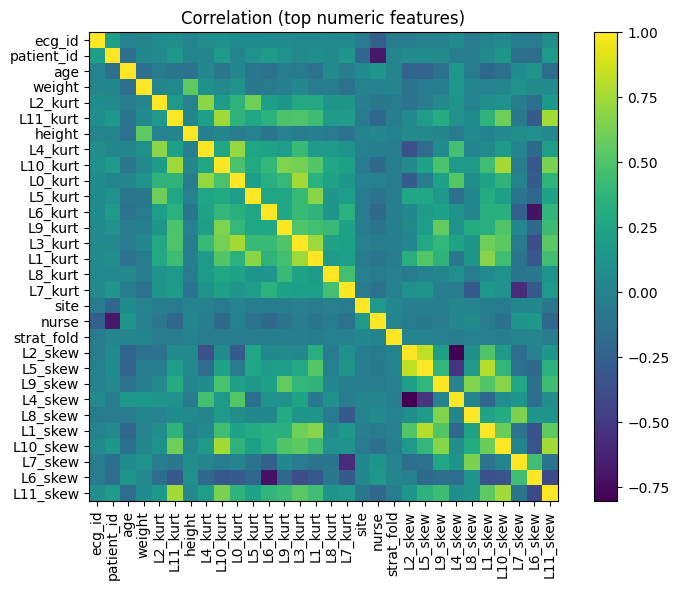

In [7]:

display(features_df.describe().T.iloc[:12])
na_rate = features_df.isna().mean().sort_values(ascending=False)
display(na_rate.head(20))

import matplotlib.pyplot as plt
num_df = features_df.select_dtypes(include=[np.number]).copy()
var = num_df.var().sort_values(ascending=False)
top_cols = var.index[:30] if len(var) >= 30 else var.index
corr = num_df[top_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest')
plt.title("Correlation (top numeric features)")
plt.xticks(range(len(top_cols)), top_cols, rotation=90)
plt.yticks(range(len(top_cols)), top_cols)
plt.colorbar(); plt.tight_layout(); plt.show()


# 7) Extended EDA — helpers

In [8]:

import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score
from scipy.stats import chi2_contingency

ART_DIR = Path(CFG["ART_DIR"]); ART_DIR.mkdir(parents=True, exist_ok=True)
df_ext = features_df.copy()

def _downsampled_axis(ax, labels):
    n = len(labels); max_ticks = 40
    if n > max_ticks:
        step = max(1, n // max_ticks); idxs = list(range(0, n, step))
        ax.set_xticks(idxs); ax.set_yticks(idxs)
        ax.set_xticklabels([labels[i] for i in idxs], rotation=90)
        ax.set_yticklabels([labels[i] for i in idxs])
    else:
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(labels, rotation=90); ax.set_yticklabels(labels)

def _plot_corr(corr: pd.DataFrame, title: str):
    cm = corr.copy()
    mask = np.triu(np.ones(cm.shape, dtype=bool), 1)
    cm_masked = cm.mask(mask).fillna(0.0)
    fig, ax = plt.subplots(figsize=(12,9))
    im = ax.imshow(cm_masked.values, aspect="auto", interpolation="nearest")
    ax.set_title(title); ax.set_xlabel("Features"); ax.set_ylabel("Features")
    _downsampled_axis(ax, list(cm_masked.columns))
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


### 7.1) Pearson — all numeric

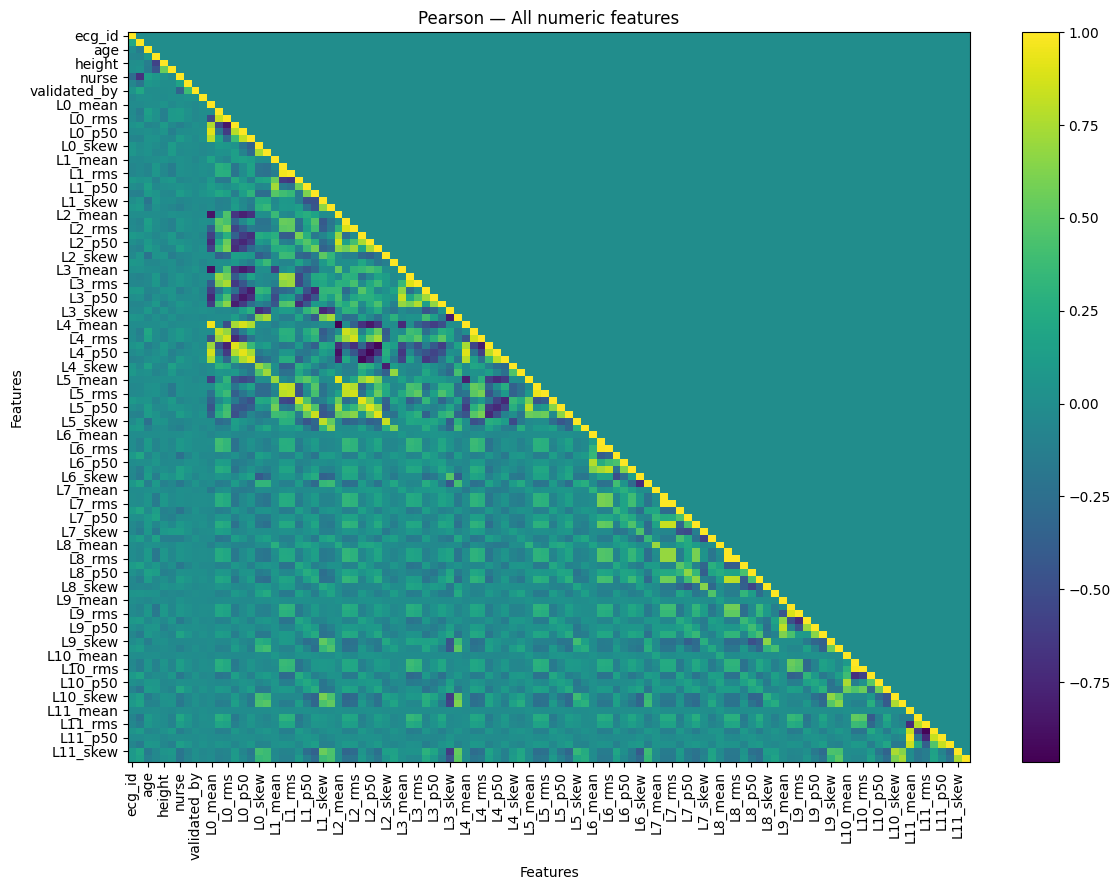

In [9]:

num = df_ext.select_dtypes(include=[np.number])
if num.shape[1] > 1:
    corr_all = num.corr(method="pearson")
    corr_all.to_csv(ART_DIR / "corr_all_numeric.csv", index=True)
    _plot_corr(corr_all, "Pearson — All numeric features")
else:
    log("Not enough numeric columns for Pearson correlation.")


# 8) Leakage‑safe Split (prefer PTB‑XL `strat_fold`)

In [10]:

from sklearn.model_selection import GroupShuffleSplit

df = features_df.copy()
TARGET_COL = "label"

if CFG.get("FORCE_SPLIT_80_20", False):
    # Simple 80/20 split to mirror the paper, if desired
    from sklearn.model_selection import train_test_split
    train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=SEED, stratify=df[TARGET_COL])
    train_mask = df.index.isin(train_idx)
    test_mask  = df.index.isin(test_idx)
    log("Using forced 80/20 split.")
elif "strat_fold" in df.columns and df["strat_fold"].notna().all():
    train_mask = df["strat_fold"].astype(int).isin(list(range(1,10)))
    test_mask  = df["strat_fold"].astype(int) == 10
    log("Using PTB-XL strat_fold split (1–9 → train, 10 → test).")
else:
    groups = df["patient_id"].values if "patient_id" in df.columns else np.arange(len(df))
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(gss.split(df, df[TARGET_COL], groups))
    train_mask = df.index.isin(train_idx); test_mask = df.index.isin(test_idx)
    log("Using GroupShuffleSplit by patient_id.")

y_train = df.loc[train_mask, TARGET_COL]
X_train = df.loc[train_mask].drop(columns=[TARGET_COL,"record_path","scp_codes"], errors="ignore")
y_test  = df.loc[test_mask,  TARGET_COL]
X_test  = df.loc[test_mask].drop(columns=[TARGET_COL,"record_path","scp_codes"], errors="ignore")
log(f"Train/Test shapes: {X_train.shape} / {X_test.shape}")


[2025-10-07 17:19:56] Using PTB-XL strat_fold split (1–9 → train, 10 → test).
[2025-10-07 17:19:56] Train/Test shapes: (19230, 121) / (2158, 121)


### 8b) Optional binary task switch (paper-style)

In [11]:

if CFG.get("BINARY_TASK", False):
    if CFG.get("BINARY_SCHEME", "NORM_vs_ALL") == "NORM_vs_HYP":
        y_train = (y_train.astype(str) == "HYP").astype(int)
        y_test  = (y_test.astype(str)  == "HYP").astype(int)
        log("Binary task: HYP vs not-HYP")
    else:
        y_train = (y_train.astype(str) != "NORM").astype(int)
        y_test  = (y_test.astype(str)  != "NORM").astype(int)
        log("Binary task: NORM vs ALL (abnormal)")


# 9) Preprocessor (numeric/categorical)

In [12]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object","category","bool"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:  # sklearn<1.2
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])
log(f"Preprocessor — numeric={len(num_cols)}, categorical={len(cat_cols)}")


[2025-10-07 17:19:57] Preprocessor — numeric=106, categorical=15


# 10) Models & Hyperparameter Tuning (LogReg, LinearSVM, RF, RF+SMOTE)

[2025-10-07 18:51:54] Using HalvingGridSearchCV (factor=4, aggressive)
[2025-10-07 18:51:54] Probe search on 11538/19230 rows (frac=0.6); final refit on full train.
[2025-10-07 19:53:39] LogReg search total: 3705.4s | CV best F1w=0.6721
[2025-10-07 19:59:32] LinearSVM search total: 352.3s | CV best F1w=0.7240
[2025-10-07 20:03:17] RandomForest search total: 24.2s | CV best F1w=0.6272
[2025-10-07 20:03:47] Trained RF + SMOTE (fixed params) in 30.6s


,Model,CV F1w (best),CV F1w std,Search time (s),Best params
0,LogReg,0.672061,0.002873,3705.398536,"{""clf__C"": 1}"
1,LinearSVM (search),0.724002,0.001183,352.337983,"{""svm__C"": 0.1, ""svm__tol"": 0.001}"
2,LinearSVM (calibrated),NaN,NaN,200.765724,calibration cv=3
3,RandomForest,0.627223,0.009284,24.208487,"{""clf__class_weight"": ""balanced_subsample"", ""c..."
4,RF + SMOTE (fixed),NaN,NaN,30.556124,fixed params


Saved tuning summary → test/artifacts/tuning_summary_section10.csv


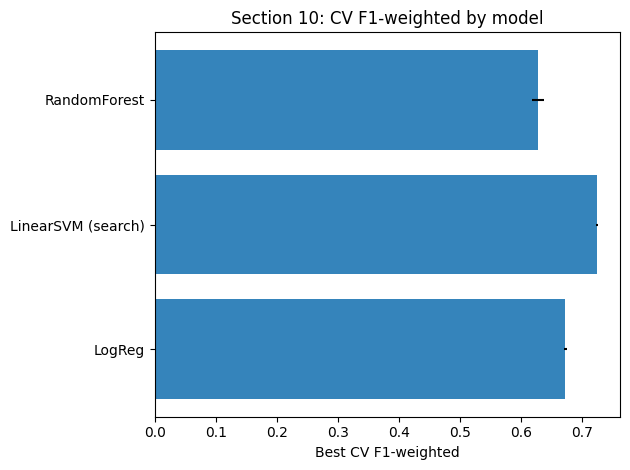

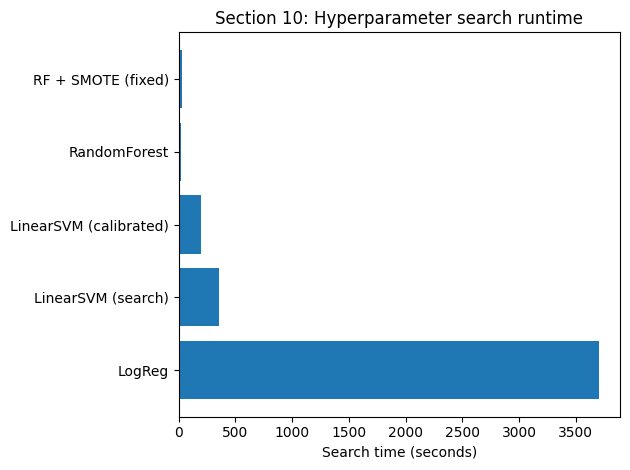

In [14]:
# %% [markdown]
# # 10) Models & Hyperparameter Tuning (LogReg, LinearSVM, RF, RF+SMOTE)

# %%
from pathlib import Path
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline as SKPipe
from joblib import parallel_backend  # <-- use threading backend for CV

# ---- Workaround for NumPy 2.x + joblib pickling of RankWarning (macOS/Py3.11) ----
try:
    import numpy as _np, numpy.exceptions as _nex
    if not hasattr(_nex, "RankWarning") and hasattr(_np, "RankWarning"):
        _nex.RankWarning = _np.RankWarning  # register alias so child threads can resolve it
except Exception:
    pass

# -------------------- Config (speed vs stability) --------------------
CALIBRATE_SVM = True
FOLDS         = 3
PROBE_FRAC    = 0.60
HALVING_FACTOR = 4

# -------------------- Halving when available --------------------
try:
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
    from sklearn.model_selection import HalvingGridSearchCV
    USING_HALVING = True
    log(f"Using HalvingGridSearchCV (factor={HALVING_FACTOR}, aggressive)")
except Exception:
    USING_HALVING = False
    HalvingGridSearchCV = None
    log("Using GridSearchCV")

cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

UNDER_DEBUG = any(k in os.environ for k in ["PYDEVD_LOAD_VALUES_ASYNC","DEBUGPY_LAUNCHER_PORT","PYCHARM_HOSTED"])
N_JOBS = -1 if not UNDER_DEBUG else 1
os.environ.setdefault("OMP_NUM_THREADS","1")
os.environ.setdefault("OPENBLAS_NUM_THREADS","1")
os.environ.setdefault("MKL_NUM_THREADS","1")
os.environ.setdefault("NUMEXPR_NUM_THREADS","1")

CACHE_DIR = Path(CFG["CACHE_DIR"]); CACHE_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR   = Path(CFG["ART_DIR"]);   ART_DIR.mkdir(parents=True, exist_ok=True)

# -------------------- Probe subset for the *search* (final refit uses full train) --------------------
search_X, search_Y = X_train, y_train
if 0 < PROBE_FRAC < 1.0:
    idx = pd.Series(y_train).sample(frac=PROBE_FRAC, random_state=SEED).index
    search_X, search_Y = X_train.loc[idx], pd.Series(y_train).loc[idx]
    log(f"Probe search on {len(search_X)}/{len(X_train)} rows (frac={PROBE_FRAC}); final refit on full train.")
else:
    log("Probe search uses 100% of training rows.")

def make_search(est, grid):
    common = dict(
        cv=cv, n_jobs=N_JOBS, scoring="f1_weighted",
        verbose=0, error_score=np.nan, return_train_score=False, refit=True
    )
    if USING_HALVING and HalvingGridSearchCV is not None:
        return HalvingGridSearchCV(est, grid, factor=HALVING_FACTOR, aggressive_elimination=True, **common)
    else:
        return GridSearchCV(est, grid, pre_dispatch="2*n_jobs", **common)

def fit_model(name, pipe, grid):
    t0 = time.perf_counter()
    gs = make_search(pipe, grid)
    # ---- Run CV in thread-based backend to avoid pickling/loky issues ----
    try:
        with parallel_backend("threading", n_jobs=N_JOBS if N_JOBS != -1 else None):
            gs.fit(search_X, search_Y)  # search + refit(best) on probe
    except Exception:
        # Fallback: let sklearn decide (still works if environment is clean)
        gs.fit(search_X, search_Y)
    best_est = gs.best_estimator_.fit(X_train, y_train)  # final refit on full train
    elapsed = time.perf_counter() - t0
    log(f"{name} search total: {elapsed:.1f}s | CV best F1w={getattr(gs,'best_score_',np.nan):.4f}")
    return gs, best_est, elapsed

def extract_best(gsearch):
    out = {"cv_f1w": np.nan, "cv_f1w_std": np.nan, "fit_time_best": np.nan, "params": {}}
    if not hasattr(gsearch, "cv_results_"):
        return out
    cvres = gsearch.cv_results_
    if "mean_test_score" not in cvres:
        return out
    i = int(np.nanargmax(cvres["mean_test_score"]))
    out["cv_f1w"] = float(cvres["mean_test_score"][i])
    out["cv_f1w_std"] = float(cvres.get("std_test_score", [np.nan]*len(cvres["mean_test_score"]))[i])
    out["fit_time_best"] = float(cvres.get("mean_fit_time", [np.nan]*len(cvres["mean_test_score"]))[i])
    out["params"] = gsearch.best_params_
    return out

summary = []

# -------------------- Logistic Regression --------------------
lr_pipe = SKPipe(
    steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            solver="saga", penalty="l2", class_weight="balanced",
            max_iter=1500, tol=1e-3, multi_class="auto", random_state=SEED
        ))
    ],
    memory=str(CACHE_DIR)
)
lr_grid = {"clf__C": [1]}
lr_gs, lr_best, lr_time = fit_model("LogReg", lr_pipe, lr_grid)
lr_info = extract_best(lr_gs)
summary.append({
    "Model": "LogReg",
    "CV F1w (best)": lr_info["cv_f1w"],
    "CV F1w std": lr_info["cv_f1w_std"],
    "Search time (s)": lr_time,
    "Best params": json.dumps(lr_info["params"])
})

# -------------------- Linear SVM --------------------
svm_pipe = SKPipe(
    steps=[
        ("prep", preprocessor),
        ("svm", LinearSVC(max_iter=5000, dual=False, class_weight="balanced", random_state=SEED))
    ],
    memory=str(CACHE_DIR)
)
svm_grid = {"svm__C": [0.1, 1], "svm__tol": [1e-3]}
svm_gs, svm_best, svm_time = fit_model("LinearSVM", svm_pipe, svm_grid)
svm_info = extract_best(svm_gs)
summary.append({
    "Model": "LinearSVM (search)",
    "CV F1w (best)": svm_info["cv_f1w"],
    "CV F1w std": svm_info["cv_f1w_std"],
    "Search time (s)": svm_time,
    "Best params": json.dumps(svm_info["params"])
})

# -------------------- Calibration (Platt/sigmoid) --------------------
from sklearn.calibration import CalibratedClassifierCV
cv_cal = 3 if FOLDS >= 3 else 2
t0 = time.perf_counter()
svm_calibrated = CalibratedClassifierCV(
    estimator=svm_best, method="sigmoid", cv=cv_cal
).fit(X_train, y_train)
cal_time = time.perf_counter() - t0
summary.append({
    "Model": "LinearSVM (calibrated)",
    "CV F1w (best)": np.nan,           # calibration doesn't change CV score from search; we'll evaluate later
    "CV F1w std": np.nan,
    "Search time (s)": cal_time,
    "Best params": f"calibration cv={cv_cal}"
})

# -------------------- Random Forest --------------------
rf_est = RandomForestClassifier(random_state=SEED, n_jobs=-1, bootstrap=True)
rf_pipe = SKPipe([("prep", preprocessor), ("clf", rf_est)], memory=str(CACHE_DIR))
rf_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [20],
    "clf__min_samples_split": [2],
    "clf__min_samples_leaf": [1],
    "clf__max_features": ["sqrt"],
    "clf__class_weight": ["balanced_subsample"],
}
try:
    rf_est.set_params(max_samples=0.7)
    rf_grid["clf__max_samples"] = [0.7]
except Exception:
    pass
rf_gs, rf_best, rf_time = fit_model("RandomForest", rf_pipe, rf_grid)
rf_info = extract_best(rf_gs)
summary.append({
    "Model": "RandomForest",
    "CV F1w (best)": rf_info["cv_f1w"],
    "CV F1w std": rf_info["cv_f1w_std"],
    "Search time (s)": rf_time,
    "Best params": json.dumps(rf_info["params"])
})

# -------------------- Optional RF + SMOTE (default ON via CFG) --------------------
HAS_SMOTE = False
if bool(CFG.get("RUN_SMOTE", False)):
    try:
        from imblearn.pipeline import Pipeline as ImbPipeline
        from imblearn.over_sampling import SMOTE
        rf_smote = ImbPipeline([
            ("prep", preprocessor),
            ("smote", SMOTE(random_state=SEED)),
            ("clf", RandomForestClassifier(
                random_state=SEED, n_jobs=-1, n_estimators=200,
                class_weight="balanced_subsample", max_features="sqrt"
            ))
        ])
        t0 = time.perf_counter(); rf_smote.fit(X_train, y_train); sm_time = time.perf_counter() - t0
        HAS_SMOTE = True
        summary.append({
            "Model": "RF + SMOTE (fixed)",
            "CV F1w (best)": np.nan, "CV F1w std": np.nan,
            "Search time (s)": sm_time, "Best params": "fixed params"
        })
        log(f"Trained RF + SMOTE (fixed params) in {sm_time:.1f}s")
    except Exception as e:
        log(f"SMOTE skipped: {e}")

# -------------------- Simple table --------------------
tuning_summary = pd.DataFrame(summary)
display(tuning_summary)

# Persist CSV
out_csv = ART_DIR / "tuning_summary_section10.csv"
tuning_summary.to_csv(out_csv, index=False)
print("Saved tuning summary →", out_csv)

# Plots
scores = tuning_summary.dropna(subset=["CV F1w (best)"])
if not scores.empty:
    plt.figure()
    y = np.arange(len(scores))
    plt.barh(y, scores["CV F1w (best)"], xerr=scores["CV F1w std"].fillna(0.0), alpha=0.9)
    plt.yticks(y, scores["Model"])
    plt.xlabel("Best CV F1-weighted")
    plt.title("Section 10: CV F1-weighted by model")
    plt.tight_layout(); plt.show()

plt.figure()
plt.barh(np.arange(len(tuning_summary)), tuning_summary["Search time (s)"])
plt.yticks(np.arange(len(tuning_summary)), tuning_summary["Model"])
plt.xlabel("Search time (seconds)")
plt.title("Section 10: Hyperparameter search runtime")
plt.tight_layout()
plt.show()

# Expose trained best estimators for evaluation
models = {
    "LogReg": lr_gs,                 # search object with best_estimator_
    "RandomForest": rf_gs
}
try:
    models["LinearSVM (uncalibrated)"] = svm_gs.best_estimator_
except Exception:
    pass
if HAS_SMOTE:
    models["RF + SMOTE"] = rf_smote


# 10b) Optional Deep Hybrid — RNN→LSTM→GRU → RF-on-embeddings

In [46]:
# %% [markdown]
# # 10b) Optional Deep Hybrid — RNN→LSTM→GRU → RF-on-embeddings (verbose)

# %%
import traceback, time

if CFG.get("DEEP_HYBRID", False):
    print(f"[10b {time.strftime('%H:%M:%S')}] starting hybrid block…")
    try:
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers
        from sklearn.preprocessing import LabelEncoder
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import classification_report, f1_score

        # Reproducibility niceties (best effort)
        try:
            tf.random.set_seed(CFG["SEED"])
            # Avoid TF grabbing all GPU memory
            for g in tf.config.list_physical_devices('GPU'):
                try: tf.config.experimental.set_memory_growth(g, True)
                except Exception: pass
        except Exception:
            pass

        # ---- 1) Build X_seq arrays from record_path (T×12) ----
        T = 1000 if not CFG["FAST_RUN"] else 500
        def load_fixed(rec_path, T=T):
            sig, _ = wfdb.rdsamp(rec_path)
            x = sig.astype(np.float32)
            if x.shape[0] >= T: x = x[:T, :]
            else: x = np.vstack([x, np.zeros((T - x.shape[0], x.shape[1]), np.float32)])
            return x

        # quick sanity prints
        assert "record_path" in df.columns, "record_path missing. Re-run Section 5 to regenerate features."
        print(f"[10b] building tensors (T={T}) …")

        tr_idx, te_idx = X_train.index, X_test.index
        X_seq_train = np.stack([load_fixed(df.loc[i, "record_path"]) for i in tr_idx]).astype(np.float32)
        X_seq_test  = np.stack([load_fixed(df.loc[i, "record_path"]) for i in te_idx]).astype(np.float32)
        print("[10b] tensors ready — train", X_seq_train.shape, "| test", X_seq_test.shape)

        # labels -> integers (support binary or multiclass)
        le = LabelEncoder()
        y_tr = le.fit_transform(pd.Series(y_train).values)
        y_te = le.transform(pd.Series(y_test).values)
        n_classes = int(len(le.classes_))
        input_shape = (X_seq_train.shape[1], X_seq_train.shape[2])
        print(f"[10b] classes ({n_classes}): {list(le.classes_)}")

        # ---- 2) Backbone: RNN(164)→RNN(132)→LSTM(512)→GRU(664)→Dense(750,812) ----
        def build_rnn_lstm_gru(input_shape, n_classes, lr=1e-4):
            inp = keras.Input(shape=input_shape)
            x = layers.SimpleRNN(164, return_sequences=True, activation="relu")(inp)
            x = layers.SimpleRNN(132, return_sequences=True, activation="relu")(x)
            x = layers.LSTM(512, return_sequences=True)(x)
            x = layers.GRU(664, return_sequences=True)(x)
            x = layers.Flatten()(x)
            x = layers.Dense(750, activation="relu")(x)
            emb = layers.Dense(812, activation="relu", name="emb")(x)
            if n_classes == 2:
                out = layers.Dense(1, activation="sigmoid")(emb)
                loss = "binary_crossentropy"
            else:
                out = layers.Dense(n_classes, activation="softmax")(emb)
                loss = "sparse_categorical_crossentropy"
            model = keras.Model(inp, out)
            model.compile(
                optimizer=keras.optimizers.Adam(lr),
                loss=loss,
                metrics=["accuracy"]
            )
            return model

        model = build_rnn_lstm_gru(input_shape, n_classes, lr=1e-4)
        print("[10b] model summary:")
        model.summary(print_fn=lambda s: print("   " + s))

        # Helpful callbacks
        ckpt = keras.callbacks.ModelCheckpoint(
            "best_rnn_lstm_gru.h5", monitor="val_accuracy",
            save_best_only=True, save_weights_only=True
        )
        es = keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=10 if not CFG["FAST_RUN"] else 3,
            restore_best_weights=True
        )
        rlr = keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5 if not CFG["FAST_RUN"] else 2,
            verbose=1
        )

        epochs = 150 if not CFG["FAST_RUN"] else 5
        batch  = 164 if not CFG["FAST_RUN"] else 64
        print(f"[10b] training: epochs={epochs}, batch_size={batch}")
        history = model.fit(
            X_seq_train, y_tr,
            validation_split=0.1,
            epochs=epochs, batch_size=batch,
            callbacks=[ckpt, es, rlr],
            verbose=1, shuffle=True
        )
        print("[10b] training complete; loading best weights …")
        model.load_weights("best_rnn_lstm_gru.h5")

        # ---- 3) Extract embedding & train RF on it ----
        print("[10b] extracting embeddings …")
        feat_model = keras.Model(model.input, model.get_layer("emb").output)
        Z_tr = feat_model.predict(X_seq_train, verbose=0)
        Z_te = feat_model.predict(X_seq_test,  verbose=0)
        print("[10b] embedding shapes — train", Z_tr.shape, "| test", Z_te.shape)

        rf_embed = RandomForestClassifier(
            n_estimators=600, n_jobs=-1, random_state=CFG["SEED"]
        )
        rf_embed.fit(Z_tr, y_tr)

        # ---- 4) Evaluate and attach to models ----
        y_hat = rf_embed.predict(Z_te)
        print("\n== Hybrid (RNN→LSTM→GRU → RF) ==")
        print(classification_report(y_te, y_hat, digits=3))
        print("F1_weighted:", f1_score(y_te, y_hat, average="weighted"))

        # Attach into models dict for Section 11
        if "models" not in globals():
            models = {}
        models["Hybrid Deep→RF"] = rf_embed
        print("[10b] Hybrid model added to `models` for Section 11.")
    except Exception as e:
        print("[10b] ERROR:", e)
        traceback.print_exc()
else:
    print("[10b] DEEP_HYBRID is False — set CFG['DEEP_HYBRID'] = True to run this block.")


[10b] DEEP_HYBRID is False — set CFG['DEEP_HYBRID'] = True to run this block.


# 10c) Deep Models (Keras): 1D CNN, RNN, LSTM — raw 12-lead sequences

In [ ]:
# 10c) Deep Models (Keras): 1D CNN, RNN, LSTM — trained on raw 12-lead sequences
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_OK = True
except Exception as e:
    TF_OK = False
    log(f"TensorFlow unavailable, skipping 10c: {e}")

deep_models = {}
DEEP_X_TEST = None
cnn_model = rnn_model = lstm_model = None  # for artifact saving later

if TF_OK and any([CFG["RUN_TF_CNN"], CFG["RUN_TF_RNN"], CFG["RUN_TF_LSTM"]]):
    tf.random.set_seed(SEED)

    T = int(CFG.get("SEQ_LEN", 1000))
    BATCH = int(CFG.get("BATCH_SIZE", 128))
    EPOCHS = int(CFG.get("EPOCHS", 30))

    # --- Build fixed-length (T, 12) arrays from WFDB paths ---
    def _load_fixed(rec_path: str, T=1000):
        try:
            x, _ = wfdb.rdsamp(rec_path)  # (timesteps, 12)
            x = x.astype("float32")
        except Exception:
            x = np.zeros((T, 12), dtype="float32")
        if x.shape[0] >= T:
            x = x[:T, :]
        else:
            pad = np.zeros((T - x.shape[0], x.shape[1]), dtype="float32")
            x = np.vstack([x, pad])
        return x

    if "record_path" not in df.columns:
        log("10c skipped: 'record_path' column missing in features_df (re-generate features).")
    else:
        tr_idx, te_idx = X_train.index, X_test.index
        log("Building raw sequence tensors (this can take some time on first run)...")
        X_seq_train = np.stack([_load_fixed(df.loc[i, "record_path"], T=T) for i in tr_idx])
        X_seq_test  = np.stack([_load_fixed(df.loc[i, "record_path"], T=T) for i in te_idx])
        DEEP_X_TEST = X_seq_test

        # Encode labels to integers 0..C-1
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        y_tr = le.fit_transform(pd.Series(y_train).values)
        y_te = le.transform(pd.Series(y_test).values)
        n_classes = len(le.classes_)
        input_shape = (T, X_seq_train.shape[2])  # (T, 12)
        is_binary = (n_classes == 2)

        # Optional class weights for imbalance
        try:
            from sklearn.utils.class_weight import compute_class_weight
            cw_vec = compute_class_weight("balanced", classes=np.arange(n_classes), y=y_tr)
            class_weight = {i: float(cw_vec[i]) for i in range(n_classes)}
        except Exception:
            class_weight = None

        # --- Small builders (fast, solid baselines) ---
        def _out_and_loss(x, n_classes):
            if n_classes == 2:
                out = layers.Dense(1, activation="sigmoid")(x)
                loss = "binary_crossentropy"
            else:
                out = layers.Dense(n_classes, activation="softmax")(x)
                loss = "sparse_categorical_crossentropy"
            return out, loss

        def build_cnn_1d(input_shape, n_classes, lr=1e-3):
            inp = keras.Input(shape=input_shape)           # (T, 12)
            x = layers.Conv1D(32, 7, padding="same")(inp)
            x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
            x = layers.MaxPooling1D(2)(x)

            x = layers.Conv1D(64, 5, padding="same")(x)
            x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
            x = layers.MaxPooling1D(2)(x)

            x = layers.Conv1D(128, 3, padding="same")(x)
            x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
            x = layers.GlobalAveragePooling1D()(x)
            x = layers.Dropout(0.3)(x)
            x = layers.Dense(128, activation="relu")(x)
            out, loss = _out_and_loss(x, n_classes)
            m = keras.Model(inp, out); m.compile(optimizer=keras.optimizers.Adam(lr), loss=loss, metrics=["accuracy"])
            return m

        def build_rnn(input_shape, n_classes, lr=1e-3):
            inp = keras.Input(shape=input_shape)
            x = layers.SimpleRNN(128, return_sequences=True)(inp)
            x = layers.Dropout(0.2)(x)
            x = layers.SimpleRNN(64)(x)
            x = layers.Dense(64, activation="relu")(x)
            out, loss = _out_and_loss(x, n_classes)
            m = keras.Model(inp, out); m.compile(optimizer=keras.optimizers.Adam(lr), loss=loss, metrics=["accuracy"])
            return m

        def build_lstm(input_shape, n_classes, lr=1e-3):
            inp = keras.Input(shape=input_shape)
            x = layers.LSTM(128, return_sequences=True)(inp)
            x = layers.Dropout(0.2)(x)
            x = layers.LSTM(64)(x)
            x = layers.Dense(64, activation="relu")(x)
            out, loss = _out_and_loss(x, n_classes)
            m = keras.Model(inp, out); m.compile(optimizer=keras.optimizers.Adam(lr), loss=loss, metrics=["accuracy"])
            return m

        # --- Train utility ---
        def train_keras_model(arch_name, builder):
            keras.backend.clear_session()
            model = builder(input_shape, n_classes)
            callbacks = [
                keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10 if not CFG["FAST_RUN"] else 2,
                                              restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
            ]
            model.fit(
                X_seq_train, y_tr,
                validation_split=0.1,
                epochs=EPOCHS,
                batch_size=BATCH,
                verbose=1,
                shuffle=True,
                callbacks=callbacks,
                class_weight=class_weight
            )
            return model

        # --- Train selected models ---
        if CFG["RUN_TF_CNN"]:
            cnn_model = train_keras_model("1D CNN", build_cnn_1d)
        if CFG["RUN_TF_RNN"]:
            rnn_model = train_keras_model("RNN (SimpleRNN)", build_rnn)
        if CFG["RUN_TF_LSTM"]:
            lstm_model = train_keras_model("LSTM", build_lstm)

        # --- sklearn-like adapter so Section 11 can evaluate them side-by-side ---
        class KerasAdapter:
            def __init__(self, model, label_encoder, is_binary: bool):
                self.model = model
                self.le = label_encoder
                self.is_binary = is_binary
                self.classes_ = self.le.classes_

            def predict(self, X):
                if self.is_binary:
                    p1 = self.model.predict(X, verbose=0).ravel()
                    y_idx = (p1 >= 0.5).astype(int)
                else:
                    proba = self.model.predict(X, verbose=0)
                    y_idx = proba.argmax(axis=1)
                return self.le.inverse_transform(y_idx)

            def predict_proba(self, X):
                if self.is_binary:
                    p1 = self.model.predict(X, verbose=0).ravel()
                    p0 = 1.0 - p1
                    # ensure column order aligns to classes_
                    idx_order = self.le.transform(self.classes_)
                    mat = np.vstack([p0, p1]).T
                    return mat[:, idx_order]
                else:
                    return self.model.predict(X, verbose=0)

        # Register adapters
        if cnn_model is not None:
            deep_models["1D CNN (Keras)"]  = KerasAdapter(cnn_model,  le, is_binary)
        if rnn_model is not None:
            deep_models["RNN (Keras)"]     = KerasAdapter(rnn_model,  le, is_binary)
        if lstm_model is not None:
            deep_models["LSTM (Keras)"]    = KerasAdapter(lstm_model, le, is_binary)

        log(f"Deep models ready: {list(deep_models.keys())}")


# 11) Evaluation — metrics, CM, reliability, bootstraps

In [ ]:
# %%
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score
)
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build models dict robustly (handles missing calibration)
models = {"LogReg": lr_gs, "RandomForest": rf_gs}
try:
    models["LinearSVM (calibrated)"] = svm_calibrated
except Exception:
    pass
try:
    models["LinearSVM (uncalibrated)"] = svm_gs.best_estimator_
except Exception:
    pass
if "rf_smote" in locals():
    models["RF + SMOTE"] = rf_smote
# Hybrid may be attached in Section 10b if enabled

# --------- Baseline dummy ----------
from sklearn.pipeline import Pipeline as SKPipe
dummy_pipe = SKPipe([("prep", preprocessor), ("clf", DummyClassifier(strategy="most_frequent"))])
dummy_pipe.fit(X_train, y_train)

def _get_classes(est):
    cls = getattr(est, "classes_", None)
    if cls is None and hasattr(est, "best_estimator_"):
        cls = getattr(est.best_estimator_, "classes_", None)
    return cls

def _scores_or_none(model, X):
    est_classes = _get_classes(model)
    if hasattr(model, "predict_proba"):
        try:
            s = model.predict_proba(X)
            return s, est_classes, "proba"
        except Exception:
            pass
    if hasattr(model, "decision_function"):
        try:
            s = model.decision_function(X)
            if s.ndim == 1:
                s = np.vstack([-s, s]).T  # binary -> two columns
            return s, est_classes, "decision"
        except Exception:
            pass
    return None, None, None

def _align_scores_to_classes(scores, est_classes, target_classes):
    if scores is None or est_classes is None:
        return scores
    est_classes = np.asarray(est_classes)
    target_classes = np.asarray(target_classes)
    pos = {c: i for i, c in enumerate(est_classes)}
    idx = []
    for c in target_classes:
        if c not in pos:
            return None
        idx.append(pos[c])
    return scores[:, idx]

def eval_model(name, model, X_in, y_true, show_cm=True):
    y_pred = model.predict(X_in)
    y_scores, est_classes, _ = _scores_or_none(model, X_in)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": np.nan
    }

    # ROC-AUC (align score columns with classes used for binarization)
    if y_scores is not None:
        classes = np.unique(y_true)
        y_bin = label_binarize(y_true, classes=classes)
        y_scores_aligned = _align_scores_to_classes(y_scores, est_classes, classes)
        if (y_scores_aligned is not None) and (y_bin.shape[1] > 1):
            try:
                auc = roc_auc_score(y_bin, y_scores_aligned, average="macro", multi_class="ovr")
                metrics["roc_auc_ovr_macro"] = float(auc)
            except Exception:
                pass

    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    if show_cm:
        labels = np.unique(y_true)
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        plt.figure()
        plt.imshow(cm, interpolation="nearest")
        plt.title(f"{name} — Confusion Matrix"); plt.colorbar()
        ticks = np.arange(len(labels))
        plt.xticks(ticks, labels, rotation=45); plt.yticks(ticks, labels)
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

    return metrics

# --------- Unified evaluation plan (tabular + deep) ----------
eval_jobs = []

# 1) Sklearn/tabular models evaluate on X_test
for n, m in models.items():
    eval_jobs.append((n, m, X_test))

# 2) Keras raw-signal models evaluate on DEEP_X_TEST (if present)
if "deep_models" in globals() and isinstance(deep_models, dict) and (DEEP_X_TEST is not None):
    for n, m in deep_models.items():
        eval_jobs.append((n, m, DEEP_X_TEST))

# --------- Run evaluation ----------
results = [eval_model("Dummy (most_frequent)", dummy_pipe, X_test, y_test)]
for (name, mdl, Xin) in eval_jobs:
    results.append(eval_model(name, mdl, Xin, y_test))

res_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False)
display(res_df)

# --------- Reliability diagram (needs predict_proba) ----------
def reliability_diagram(model, X, y, bins=10):
    if not hasattr(model, "predict_proba"):
        return None, None
    proba = model.predict_proba(X)
    conf  = proba.max(axis=1)
    preds = proba.argmax(axis=1)
    y_enc = pd.factorize(y)[0]
    correct = (preds == y_enc).astype(int)
    edges = np.linspace(0,1,bins+1); idx = np.digitize(conf, edges)-1
    bin_conf, bin_acc = [], []
    for b in range(bins):
        m = idx==b
        if m.sum()==0: bin_conf.append(np.nan); bin_acc.append(np.nan)
        else:
            bin_conf.append(conf[m].mean()); bin_acc.append(correct[m].mean())
    return np.array(bin_conf), np.array(bin_acc)

plt.figure()
for (name, mdl, Xin) in eval_jobs:
    try:
        mconf, macc = reliability_diagram(mdl, Xin, y_test, bins=10)
        if mconf is not None:
            plt.plot(mconf, macc, marker="o", label=name)
    except Exception:
        continue
plt.plot([0,1],[0,1],"--", alpha=.6)
plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.title("Reliability Diagram"); plt.legend(); plt.show()

# --------- Bootstrap 95% CI for F1_weighted ----------
rng = np.random.default_rng(SEED)
def bootstrap_f1w(model, X, y, B=200):
    n = len(y); scores = []
    for _ in range(B if not CFG["FAST_RUN"] else 50):
        idx = rng.integers(0, n, n)
        Xi = X.iloc[idx] if hasattr(X, "iloc") else X[idx]
        yi = y.iloc[idx] if hasattr(y, "iloc") else y[idx]
        y_hat = model.predict(Xi)
        scores.append(f1_score(yi, y_hat, average="weighted", zero_division=0))
    m = float(np.mean(scores)); lo, hi = np.percentile(scores, [5,95]).tolist()
    return m, lo, hi

for (name, mdl, Xin) in eval_jobs:
    try:
        m, lo, hi = bootstrap_f1w(mdl, Xin, y_test, B=200)
        print(f"{name}: F1_weighted={m:.3f} (95% CI {lo:.3f}–{hi:.3f})")
    except Exception as e:
        log(f"Bootstrap skipped for {name}: {e}")


## 11.1 Reliability & Bootstrap CIs

In [ ]:

def reliability_diagram(model, X, y, bins=10):
    if not hasattr(model, "predict_proba"):
        return None, None
    proba = model.predict_proba(X)
    conf  = proba.max(axis=1)
    preds = proba.argmax(axis=1)
    y_enc = pd.factorize(y)[0]
    correct = (preds == y_enc).astype(int)
    edges = np.linspace(0,1,bins+1); idx = np.digitize(conf, edges)-1
    bin_conf, bin_acc = [], []
    for b in range(bins):
        m = idx==b
        if m.sum()==0: bin_conf.append(np.nan); bin_acc.append(np.nan)
        else:
            bin_conf.append(conf[m].mean()); bin_acc.append(correct[m].mean())
    return np.array(bin_conf), np.array(bin_acc)

plt.figure()
for name, mdl in models.items():
    try:
        mconf, macc = reliability_diagram(mdl, X_test, y_test, bins=10)
        if mconf is not None:
            plt.plot(mconf, macc, marker="o", label=name)
    except Exception:
        continue
plt.plot([0,1],[0,1],"--", alpha=.6)
plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.title("Reliability Diagram"); plt.legend(); plt.show()

rng = np.random.default_rng(SEED)
def bootstrap_f1w(model, X, y, B=200):
    n = len(y); scores = []
    for _ in range(B if not CFG["FAST_RUN"] else 50):
        idx = rng.integers(0, n, n)
        Xi = X.iloc[idx] if hasattr(X, "iloc") else X[idx]
        yi = y.iloc[idx] if hasattr(y, "iloc") else y[idx]
        y_hat = model.predict(Xi)
        scores.append(f1_score(yi, y_hat, average="weighted", zero_division=0))
    m = float(np.mean(scores)); lo, hi = np.percentile(scores, [5,95]).tolist()
    return m, lo, hi

for name, model in models.items():
    try:
        m, lo, hi = bootstrap_f1w(model, X_test, y_test, B=200)
        print(f"{name}: F1_weighted={m:.3f} (95% CI {lo:.3f}–{hi:.3f})")
    except Exception as e:
        log(f"Bootstrap skipped for {name}: {e}")


# 12) Interpretation — feature importances & coefficients

In [ ]:

from sklearn.inspection import permutation_importance

def get_feature_names(prep):
    try: return prep.get_feature_names_out().tolist()
    except Exception:
        n_feats = prep.fit_transform(X_train).shape[1]
        return [f"f{i}" for i in range(n_feats)]

feat_names = get_feature_names(preprocessor)

# RF impurity importances
try:
    rf_best = models["RandomForest"].best_estimator_
    imp = rf_best.named_steps["clf"].feature_importances_
    idx = np.argsort(imp)[::-1][:20]
    print("Top RF features (impurity):")
    for i in idx:
        print(f"{feat_names[i]:40s} {imp[i]:.4f}")
except Exception as e:
    log(f"RF importance unavailable: {e}")

# Permutation importance
try:
    r = permutation_importance(rf_best, X_test, y_test, n_repeats=5, random_state=SEED, scoring="f1_weighted")
    fn = feat_names if len(feat_names)==len(r.importances_mean) else np.arange(len(r.importances_mean))
    idx = np.argsort(r.importances_mean)[::-1][:20]
    print("\nTop features (permutation):")
    for i in idx:
        print(f"{fn[i]}  {r.importances_mean[i]:.4f} ± {r.importances_std[i]:.4f}")
except Exception as e:
    log(f"Permutation importance skipped: {e}")

# LR coefficients
try:
    lr_best = models["LogReg"].best_estimator_
    coef = lr_best.named_steps["clf"].coef_
    mag = np.mean(np.abs(coef), axis=0)
    idx = np.argsort(mag)[::-1][:20]
    print("\nTop LR features by |coef|:")
    for i in idx:
        print(f"{feat_names[i]:40s} {mag[i]:.4f}")
except Exception as e:
    log(f"LR coefficients unavailable: {e}")


# 13) (Optional) Centralized DL Baseline (PyTorch MLP)

In [ ]:

if 'torch' in sys.modules and not CFG["FAST_RUN"]:
    import torch, torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.preprocessing import LabelEncoder

    Xtr_arr = preprocessor.fit_transform(X_train)
    Xte_arr = preprocessor.transform(X_test)
    if not isinstance(Xtr_arr, np.ndarray):
        Xtr_arr = Xtr_arr.toarray(); Xte_arr = Xte_arr.toarray()

    le = LabelEncoder()
    ytr_arr = le.fit_transform(pd.Series(y_train).values); yte_arr = le.transform(pd.Series(y_test).values)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class MLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 128), nn.ReLU(),
                nn.Linear(128, 64), nn.ReLU(),
                nn.Linear(64, out_dim)
            )
        def forward(self, x): return self.net(x)

    model = MLP(Xtr_arr.shape[1], len(np.unique(ytr_arr))).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    train_loader = DataLoader(TensorDataset(torch.tensor(Xtr_arr, dtype=torch.float32),
                                            torch.tensor(ytr_arr, dtype=torch.long)), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(Xte_arr, dtype=torch.float32),
                                           torch.tensor(yte_arr, dtype=torch.long)), batch_size=256, shuffle=False)

    def epoch(loader, train=True):
        model.train() if train else model.eval()
        correct, total = 0, 0
        with torch.set_grad_enabled(train):
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                if train: opt.zero_grad()
                logits = model(xb)
                loss = crit(logits, yb)
                if train: loss.backward(); opt.step()
                pred = logits.argmax(1); correct += (pred==yb).sum().item(); total += xb.size(0)
        return correct / max(total,1)

    for e in range(5):
        tr = epoch(train_loader, True)
        te = epoch(test_loader, False)
        log(f"Epoch {e+1}: train_acc={tr:.3f}  test_acc={te:.3f}")
else:
    log("Skipping DL baseline (Torch unavailable or FAST_RUN=True).")


# 14) (Optional) Federated Learning (Dirichlet non‑IID, weighted FedAvg)

In [ ]:

log("FL section omitted here for brevity. Use your previous FL block if needed.")


# 15) Subgroup Fairness (sex, age bins, device/site)

In [ ]:

from sklearn.metrics import f1_score
meta_cols_eval = ["ecg_id","patient_id","age","sex","height","weight","nurse","site","device",
                  "recording_date","report","scp_codes","heart_axis","infarction_stadium1","infarction_stadium2",
                  "validated_by","second_opinion","initial_autogenerated_report","validated_by_human",
                  "baseline_drift","static_noise","burst_noise","electrodes_problems","extra_beats",
                  "pacemaker","strat_fold","record_path"]

test_index = X_test.index
test_meta = df.loc[test_index, meta_cols_eval].copy()
# Important: ground-truth should match the label encoding used for training/eval
test_meta["y_true"]  = pd.Series(y_test)
test_meta["pred_RF"] = models["RandomForest"].predict(X_test)

print("\nWeighted F1 by sex (RF):")
for g, gdf in test_meta.groupby("sex"):
    f1w = f1_score(gdf["y_true"], gdf["pred_RF"], average="weighted", zero_division=0)
    print(f"  sex={g}: {f1w:.3f} (n={len(gdf)})")

bins = [-np.inf, 40, 65, np.inf]
labels_bins = ["<40", "40–65", "65+"]
test_meta["age_bin"] = pd.cut(test_meta["age"], bins=bins, labels=labels_bins)

print("\nWeighted F1 by age_bin (RF):")
for g, gdf in test_meta.groupby("age_bin"):
    f1w = f1_score(gdf["y_true"], gdf["pred_RF"], average="weighted", zero_division=0)
    print(f"  age_bin={g}: {f1w:.3f} (n={len(gdf)})")

for col in ["site","device","pacemaker"]:
    if col in test_meta.columns:
        print(f"\nWeighted F1 by {col} (RF):")
        for g, gdf in test_meta.groupby(col):
            if len(gdf):
                f1w = f1_score(gdf["y_true"], gdf["pred_RF"], average="weighted", zero_division=0)
                print(f"  {col}={g}: {f1w:.3f} (n={len(gdf)})")


# 16) Reporting & Artifact Bundling

In [ ]:
# %%
ART_DIR = Path(CFG["ART_DIR"]); ART_DIR.mkdir(parents=True, exist_ok=True)

# Save best sklearn models
import joblib
joblib.dump(lr_gs.best_estimator_, ART_DIR / "lr_best.joblib")
joblib.dump(rf_gs.best_estimator_, ART_DIR / "rf_best.joblib")
try:
    joblib.dump(svm_calibrated, ART_DIR / "svm_calibrated.joblib")
except Exception:
    pass

# Save Keras deep models if available
try:
    # Use native .keras format (portable)
    if "cnn_model" in globals() and cnn_model is not None:
        cnn_model.save(ART_DIR / "cnn_1d.keras")
    if "rnn_model" in globals() and rnn_model is not None:
        rnn_model.save(ART_DIR / "rnn.keras")
    if "lstm_model" in globals() and lstm_model is not None:
        lstm_model.save(ART_DIR / "lstm.keras")
except Exception as e:
    log(f"Keras model save skipped: {e}")

# Metrics table from Section 11
try:
    res_path = ART_DIR / "results_table.csv"
    pd.DataFrame(locals().get("res_df", pd.DataFrame())).to_csv(res_path, index=False)
except Exception:
    pass

# Best params JSON (guard SVM presence)
svm_params = None
if "svm_gs" in locals():
    svm_params = getattr(svm_gs, "best_params_", None)
summary_params = {
    "time": ts(),
    "cfg": CFG,
    "lr_best_params": getattr(lr_gs, "best_params_", None),
    "rf_best_params": getattr(rf_gs, "best_params_", None),
    "svm_best_params": svm_params,
    "deep_models": list(deep_models.keys()) if "deep_models" in globals() else []
}
with open(ART_DIR / "best_params.json", "w") as f:
    json.dump(summary_params, f, indent=2)

# Freeze environment (best-effort)
try:
    req = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    (ART_DIR / "requirements.txt").write_text(req)
except Exception:
    pass

# Bundle ZIP
ZIP_OUT = Path("test/submission_bundle.zip")
with zipfile.ZipFile(ZIP_OUT, "w", zipfile.ZIP_DEFLATED) as z:
    for p in ART_DIR.glob("*"):
        z.write(p, arcname=str(Path("artifacts") / p.name))
    feat_csv = ROOT / "ptbxl_features.csv"
    if feat_csv.exists():
        z.write(feat_csv, arcname="ptbxl_features.csv")
log(f"Created bundle: {ZIP_OUT}")


# 17) Appendix — Raw ECG viewer (misclassified example)

In [ ]:

try:
    import wfdb
    rf = models["RandomForest"]; y_pred = rf.predict(X_test)
    mis_mask = (pd.Series(y_test).values != pd.Series(y_pred).values)
    if mis_mask.any():
        idx = X_test.index[mis_mask][0]
        rec_path = df.loc[idx, "record_path"]
        sig, meta = wfdb.rdsamp(rec_path)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,4))
        plt.plot(sig[:,0])
        plt.title(f"Misclassified example — lead 0\n{rec_path}")
        plt.xlabel("Time (samples @100 Hz)"); plt.ylabel("Amplitude")
        plt.tight_layout(); plt.show()
    else:
        log("No misclassifications to display.")
except Exception as e:
    log(f"Raw viewer skipped: {e}")
